In [6]:
import numpy as numpy
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from xgboost import XGBClassifier

In [7]:
raw_df=pd.read_csv(r"C:\Users\Binish\Downloads\archive (3)\parkinsons.data")
raw_df

,name,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
0,phon_R01_S01_1,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,...,0.06545,0.02211,21.033,1,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654
1,phon_R01_S01_2,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,...,0.09403,0.01929,19.085,1,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674
2,phon_R01_S01_3,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,...,0.08270,0.01309,20.651,1,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634
3,phon_R01_S01_4,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,...,0.08771,0.01353,20.644,1,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975
4,phon_R01_S01_5,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,...,0.10470,0.01767,19.649,1,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
190,phon_R01_S50_2,174.188,230.978,94.261,0.00459,0.00003,0.00263,0.00259,0.00790,0.04087,...,0.07008,0.02764,19.517,0,0.448439,0.657899,-6.538586,0.121952,2.657476,0.133050
191,phon_R01_S50_3,209.516,253.017,89.488,0.00564,0.00003,0.00331,0.00292,0.00994,0.02751,...,0.04812,0.01810,19.147,0,0.431674,0.683244,-6.195325,0.129303,2.784312,0.168895
192,phon_R01_S50_4,174.688,240.005,74.287,0.01360,0.00008,0.00624,0.00564,0.01873,0.02308,...,0.03804,0.10715,17.883,0,0.407567,0.655683,-6.787197,0.158453,2.679772,0.131728
193,phon_R01_S50_5,198.764,396.961,74.904,0.00740,0.00004,0.00370,0.00390,0.01109,0.02296,...,0.03794,0.07223,19.020,0,0.451221,0.643956,-6.744577,0.207454,2.138608,0.123306


In [ ]:
def pre_process_data(df : pd.DataFrame,show_scatter_matrix=False,show_hist=False,show_correlation_matrix=False):
    ref_df=df.copy()
    ref_df.rename(columns={
    "name"              : "Patient ID",
    "MDVP:Fo(Hz)"       : "Average Fundamental Frequency",
    "MDVP:Fhi(Hz)"      : "Highest Pitch Recorded",
    "MDVP:Flo(Hz)"      : "Lowest Pitch Recorded",
    "MDVP:Jitter(%)"    : "Main Jitter Pct Variation",
    "MDVP:Jitter(Abs)"  : "Jitter Microseconds",
    "MDVP:RAP"          : "Relative Average Perturbation",
    "MDVP:PPQ"          : "5 Cycle Smoothed Jitter",
    "Jitter:DDP"        : "DDP 3xRAP",
    "MDVP:Shimmer"      : "Core Shimmer Amplitude Ratio",
    "MDVP:Shimmer(dB)"  : "Shimmer dB",
    "Shimmer:APQ3"      : "3 Cycle Smoothed Shimmer",
    "Shimmer:APQ5"      : "5 Cycle Smoothed Shimmer",
    "MDVP:APQ"          : "11 Cycle Smoothed Shimmer",
    "Shimmer:DDA"       : "DDA 3xAPQ3",
    "NHR"               : "Noise to Harmonics Ratio",
    "HNR"               : "Harmonics to Noise Ratio",
    "status"            : "Parkinsons Positive",
    "RPDE"              : "Recurrence Period Density Entropy",
    "DFA"               : "Detrended Fluctuation Analysis",
    "spread1"           : "Nonlinear Freq Variation 1",
    "spread2"           : "Nonlinear Freq Variation 2",
    "D2"                : "Correlation Dimension",
    "PPE"               : "Pitch Period Entropy"
}, inplace=True)
    ref_df["Maximum Difference in Fundamental Frequency"]=ref_df["Highest Pitch Recorded"]-ref_df["Lowest Pitch Recorded"]
    
    if show_hist:
        ref_df.hist(figsize=(16, 12), bins=20)
        plt.tight_layout()
        plt.show()
        
    if show_correlation_matrix:
        plt.figure(figsize=(16, 12))
        sns.heatmap(
            ref_df.drop(columns=["Patient ID"]).corr(),
            annot=True,          
            fmt=".2f",           
            cmap="coolwarm",     
            center=0,            
            square=True,
            linewidths=0.5,
            annot_kws={"size": 7}
            )
        plt.xticks(rotation=45, ha='right', fontsize=8)
        plt.yticks(fontsize=8)
        plt.tight_layout()
        plt.show()

    ref_df.drop(columns=[
                 "Highest Pitch Recorded",
                 "Lowest Pitch Recorded",
                 "DDP 3xRAP",
                 "DDA 3xAPQ3",
                 "Maximum Difference in Fundamental Frequency",
                 "5 Cycle Smoothed Shimmer",
                 "11 Cycle Smoothed Shimmer",
                 "Noise to Harmonics Ratio",
                 "Shimmer dB",
                 "5 Cycle Smoothed Jitter"],inplace=True)
    y=None
    if show_scatter_matrix:
        plot_df = ref_df.drop(columns=["Patient ID"], errors='ignore')
        if "Parkinsons Positive" in plot_df.columns:
            sns.pairplot(plot_df, hue="Parkinsons Positive", corner=True, palette="husl")
        else:
            
            pd.plotting.scatter_matrix(plot_df, figsize=(15, 15))    
        plt.show()
    
    if "Parkinsons Positive" in ref_df.columns:
        y=ref_df["Parkinsons Positive"].copy()
    X=ref_df.drop(columns=["Patient ID","Parkinsons Positive"]).copy()

    return X,y

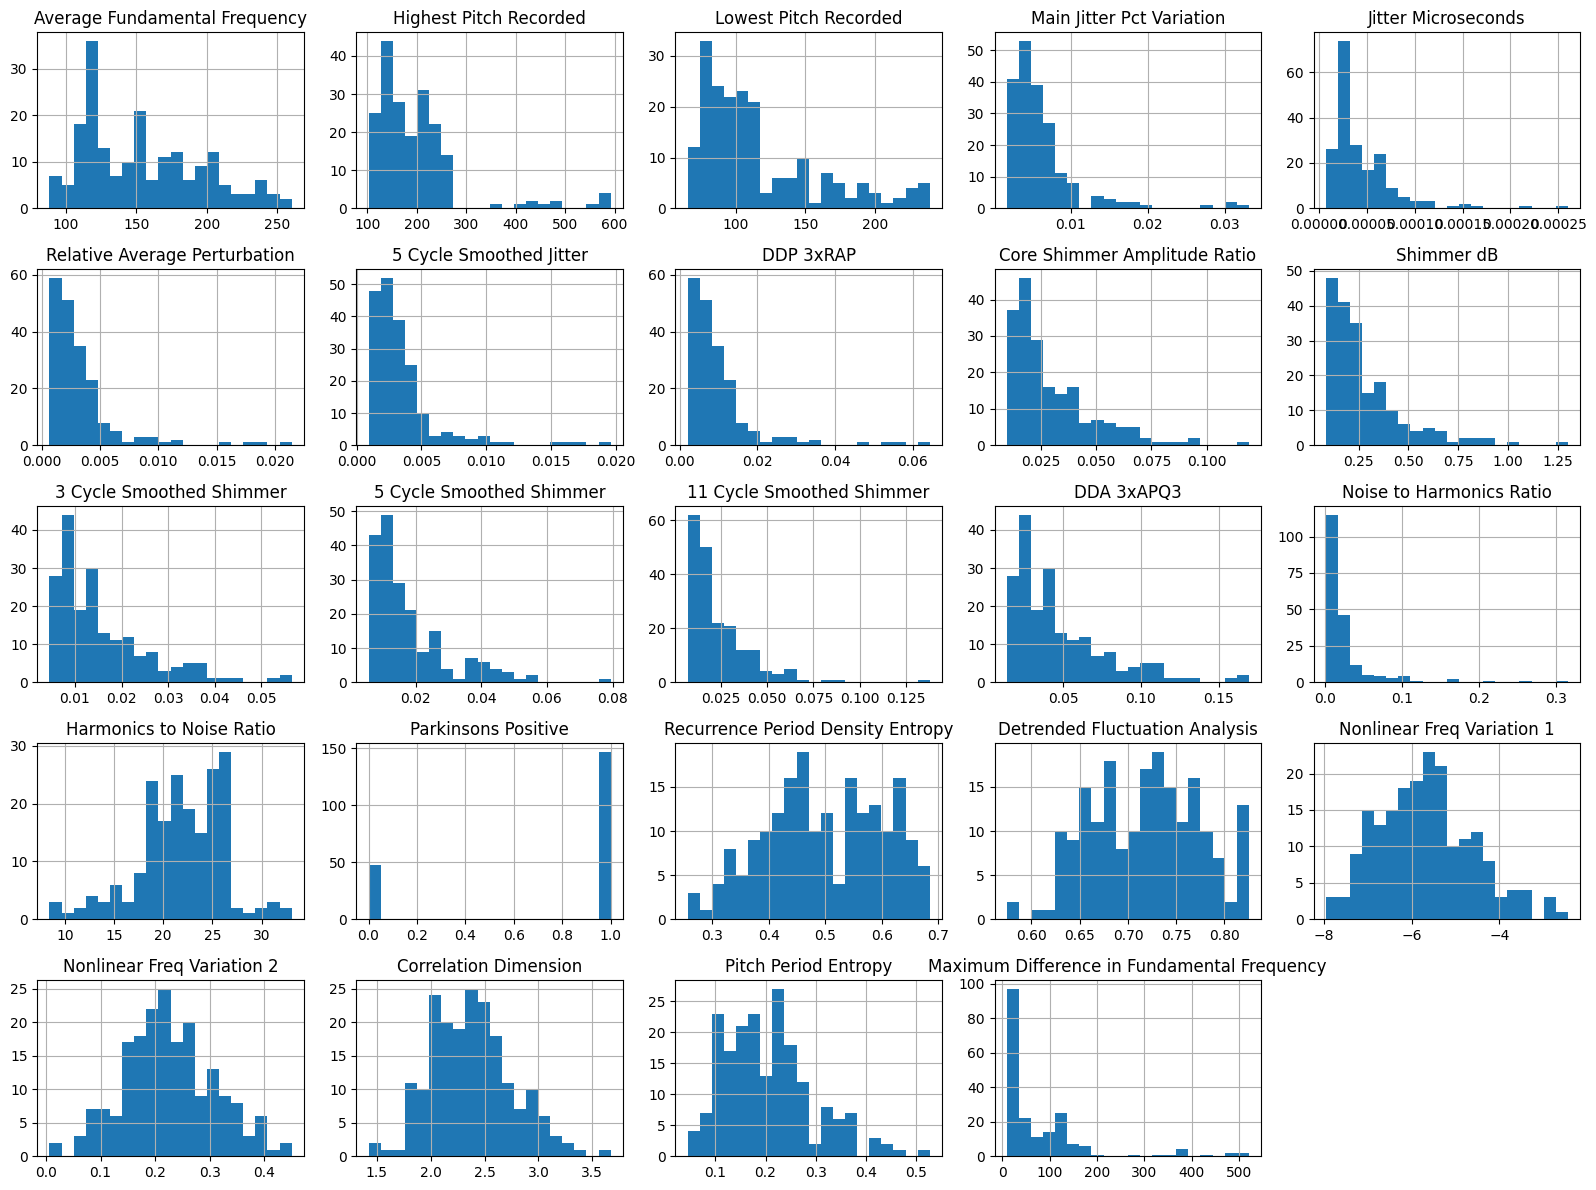

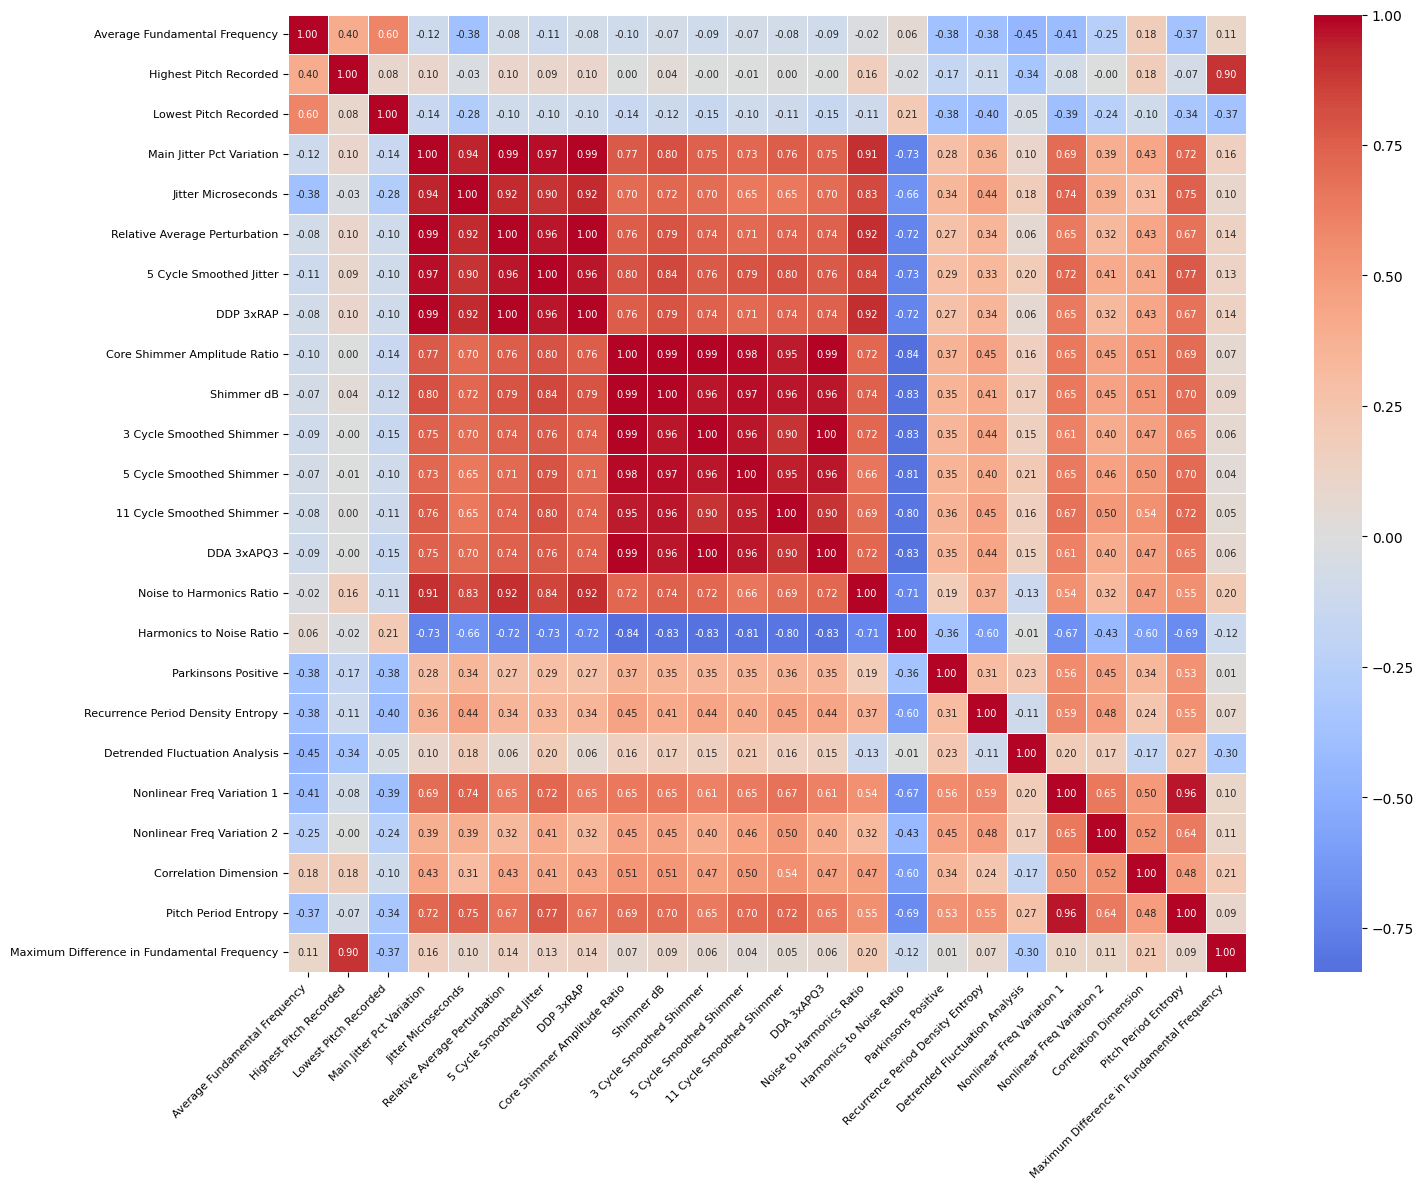

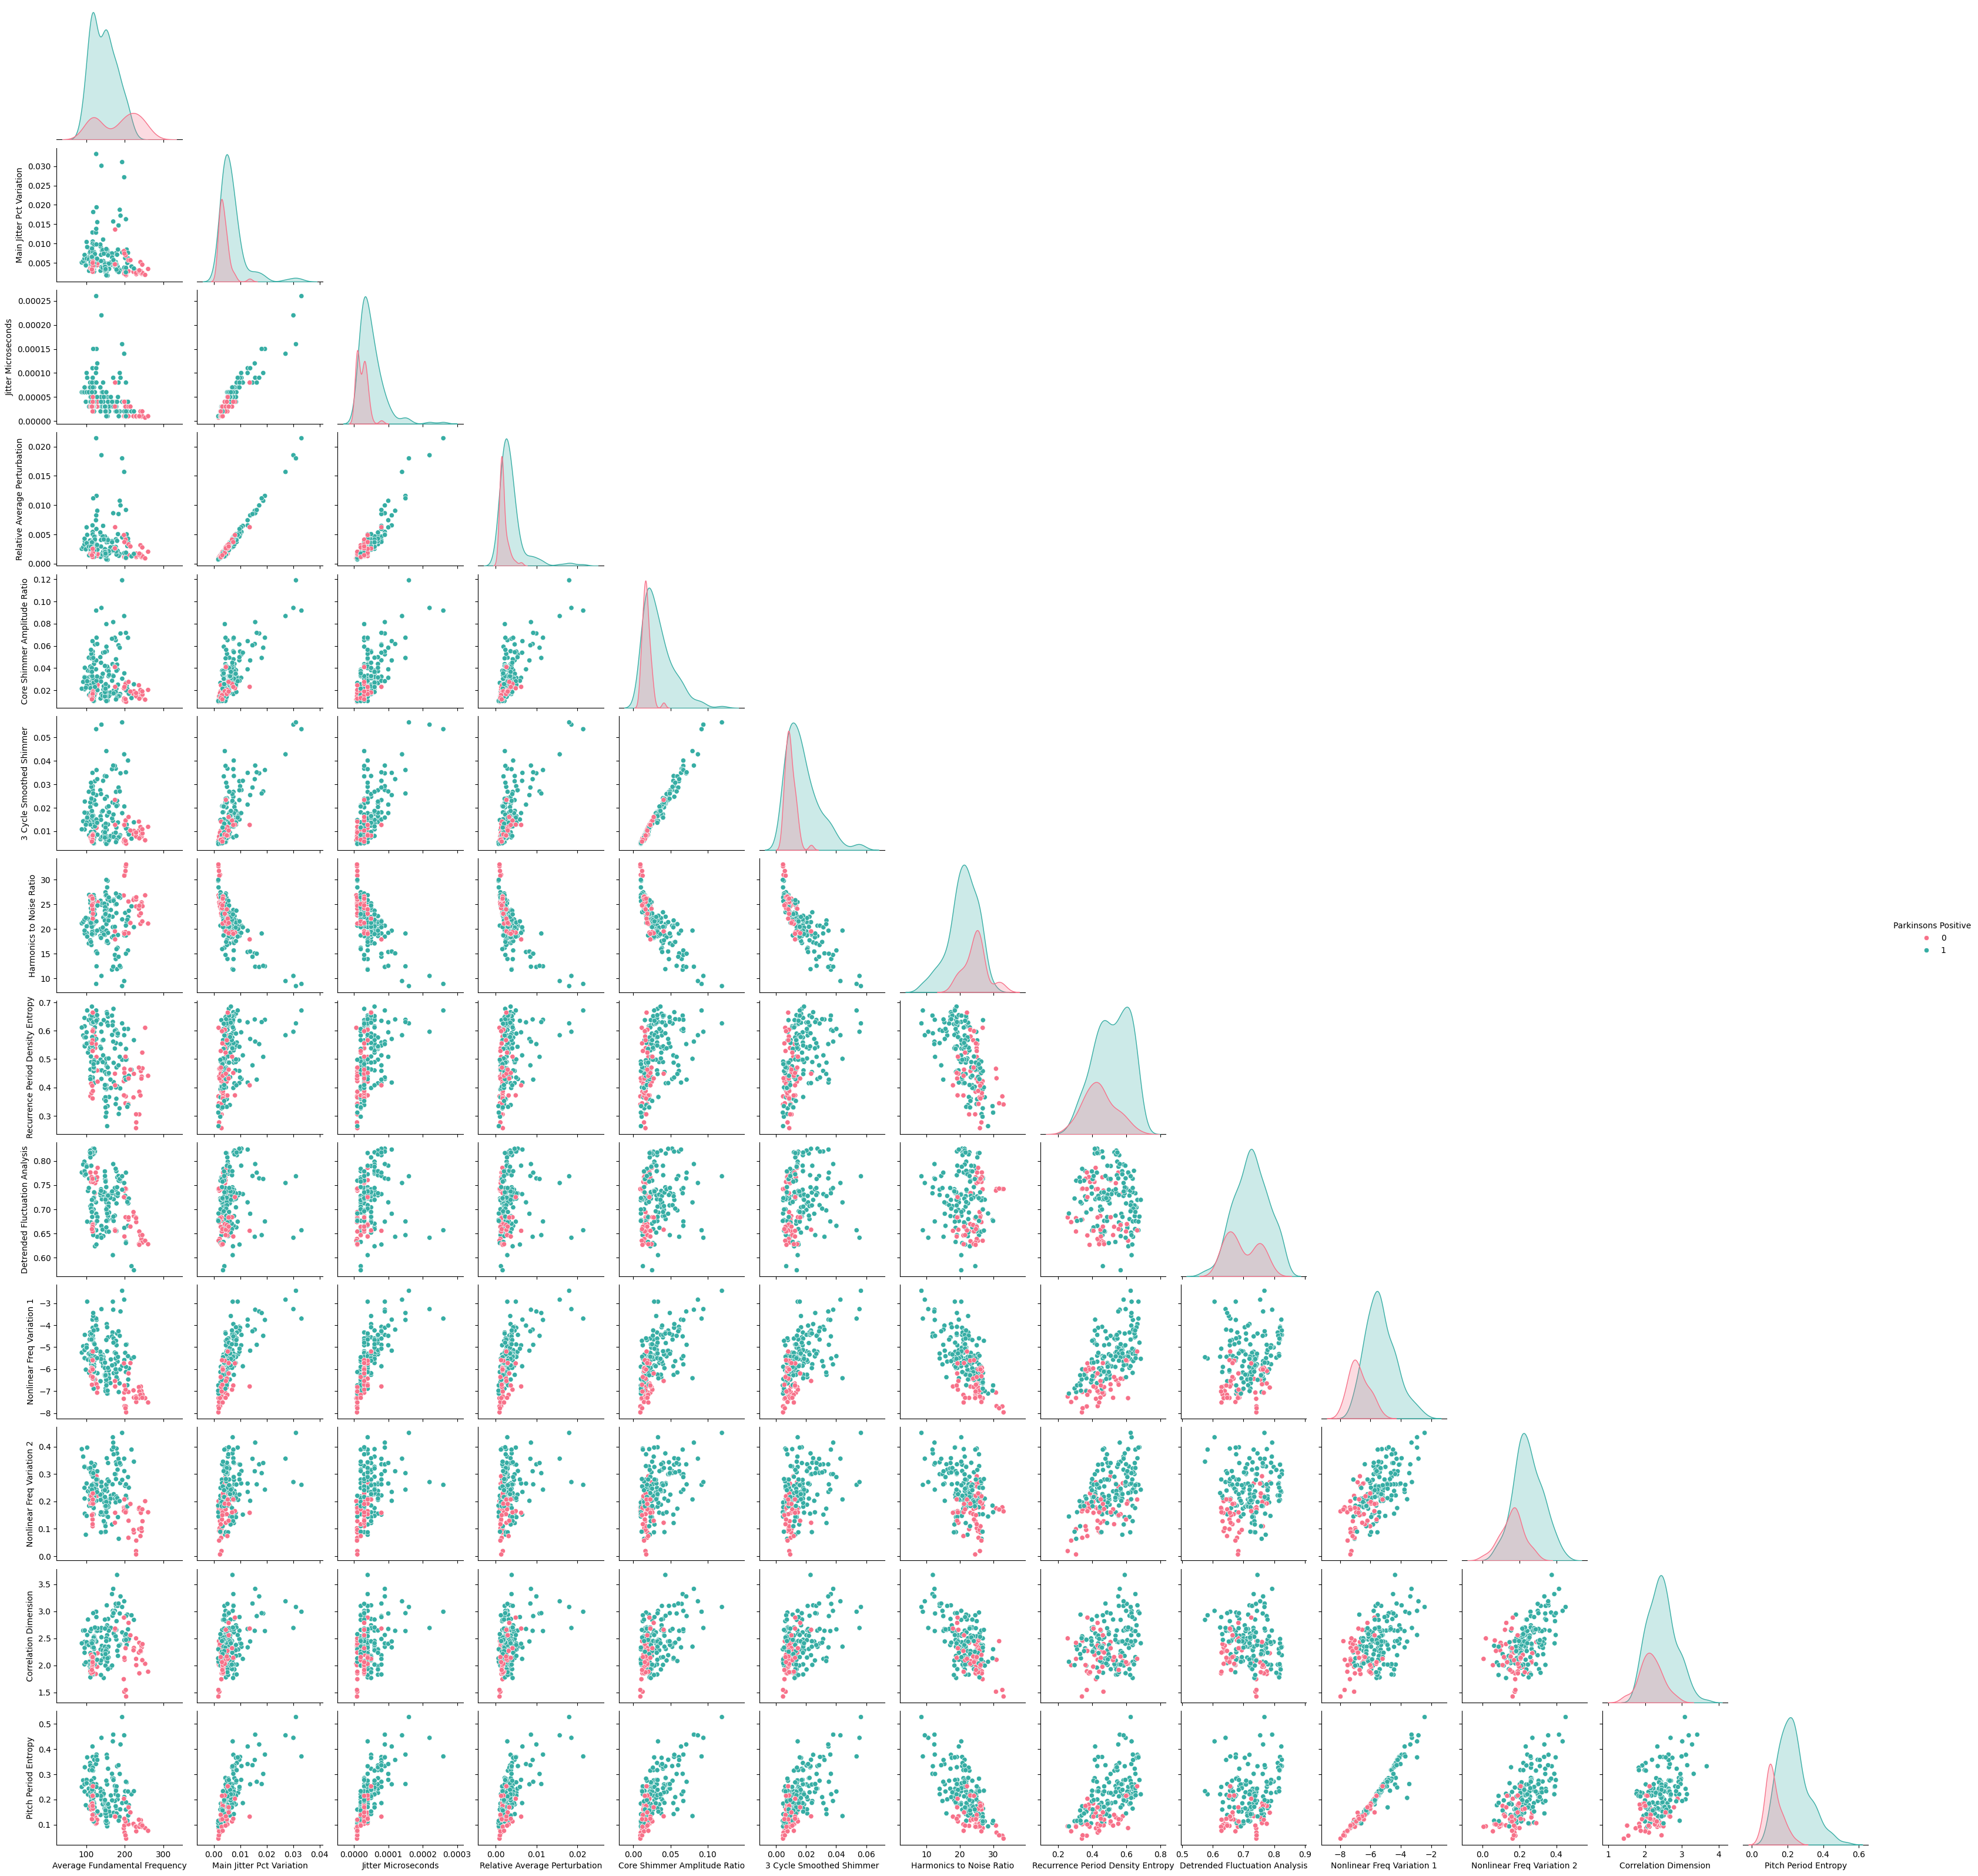

In [54]:
X,y=pre_process_data(raw_df,show_scatter_matrix=True,show_hist=True,show_correlation_matrix=True)

In [30]:
#The main pipeline starts
"""We can see that the data is highly skewed for some attributes.Since most models required data
to be Gaussian like we first do power transformation on selected attributes followed by scaling

Skewed Attributes:
1)Main Jitter Pct Variation
2)Jitter microseconds
3)RAB
4)Core Shimmer Amplitude Ratio
5)3-Cycle smoothed shimmer


"""

from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn import svm
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import train_test_split


skewed_features = [
    'Main Jitter Pct Variation',
    'Jitter Microseconds', 
    'Relative Average Perturbation',
    'Core Shimmer Amplitude Ratio',
    '3 Cycle Smoothed Shimmer'
]

normal_features=[col for col in X if col not in skewed_features]

preprocessor = ColumnTransformer([
    ('power', PowerTransformer(), skewed_features),
    ('scaler', StandardScaler(), normal_features)
])

estimators=[
    {
      "estimator": [RandomForestClassifier()],
      "estimator__n_estimators":[100,125,150,250],
      "estimator__min_samples_leaf":[1,3,5,7,9,11,13],
      "estimator__max_leaf_nodes":[2,4,8,12,16],
      "estimator__n_jobs":[3]   
    },
    {
      "estimator": [svm.SVC(probability=True)],
      "estimator__C":[10,20,30,50,60,70,100],
      "estimator__gamma":['scale','auto',0.1],
      "estimator__kernel":["rbf","linear"],
      "estimator__class_weight":["balanced"]   
    },
    {
      "estimator": [LogisticRegression(solver="saga",max_iter=2000)],
      "estimator__l1_ratio": [0.0,0.25,0.5,0.75,1.0],
      "estimator__C":[0.1,1.0,10.0,15,20],
      "estimator__class_weight":["balanced"]   
    }
    ,{
      "estimator":[XGBClassifier()],
      "estimator__n_estimators":[100,125,150,250],
      "estimator__max_depth":[8],
      "estimator__gamma": [0.01],
      "estimator__reg_lambda": [0.01],
      "estimator__subsample": [0.5,0.8,1.0],
      "estimator__colsample_bytree": [0.5,0.7,1.0],
      "estimator__grow_policy": ["lossguide"]
      
    }
]

pipeline=Pipeline([
    ("preprocessor",preprocessor),
    ("estimator",RandomForestClassifier())
])

grid_search=GridSearchCV(
    pipeline,
    estimators,
    cv=StratifiedKFold(n_splits=5,shuffle=True,random_state=42),
    scoring="f1",
    n_jobs=3,
    verbose=2,
    error_score="raise"
)

X_train,X_test,Y_train,Y_test=train_test_split(X,y,test_size=0.2,stratify=y,random_state=42)
grid_search.fit(X_train,Y_train)

Fitting 5 folds for each of 243 candidates, totalling 1215 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'estimator': [RandomForestClassifier()], 'estimator__max_leaf_nodes': [2, 4, ...], 'estimator__min_samples_leaf': [1, 3, ...], 'estimator__n_estimators': [100, 125, ...], ...}, {'estimator': [SVC(probability=True)], 'estimator__C': [10, 20, ...], 'estimator__class_weight': ['balanced'], 'estimator__gamma': ['scale', 'auto', ...], ...}, ...]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",3
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here

In [31]:
Results=pd.DataFrame(grid_search.cv_results_)

In [32]:
Results.sort_values(by=["rank_test_score"],inplace=True)
Results

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_estimator,param_estimator__max_leaf_nodes,param_estimator__min_samples_leaf,param_estimator__n_estimators,param_estimator__n_jobs,param_estimator__C,...,param_estimator__subsample,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
142,0.041640,0.006403,0.004414,0.000379,SVC(probability=True),NaN,NaN,NaN,NaN,10.0,...,NaN,"{'estimator': SVC(probability=True), 'estimato...",1.000000,0.909091,1.000000,0.958333,0.913043,0.956094,0.039807,1
140,0.041068,0.005858,0.005389,0.001088,SVC(probability=True),NaN,NaN,NaN,NaN,10.0,...,NaN,"{'estimator': SVC(probability=True), 'estimato...",1.000000,0.909091,1.000000,0.958333,0.913043,0.956094,0.039807,1
144,0.037062,0.002839,0.004821,0.000435,SVC(probability=True),NaN,NaN,NaN,NaN,10.0,...,NaN,"{'estimator': SVC(probability=True), 'estimato...",1.000000,0.909091,0.978723,0.958333,0.913043,0.951838,0.035824,3
162,0.043521,0.007032,0.006225,0.001605,SVC(probability=True),NaN,NaN,NaN,NaN,50.0,...,NaN,"{'estimator': SVC(probability=True), 'estimato...",1.000000,0.913043,0.978723,0.938776,0.913043,0.948717,0.035141,4
150,0.040167,0.008136,0.005533,0.000799,SVC(probability=True),NaN,NaN,NaN,NaN,20.0,...,NaN,"{'estimator': SVC(probability=True), 'estimato...",1.000000,0.913043,0.978723,0.938776,0.913043,0.948717,0.035141,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145,0.043643,0.002091,0.005332,0.000300,SVC(probability=True),NaN,NaN,NaN,NaN,10.0,...,NaN,"{'estimator': SVC(probability=True), 'estimato...",0.851064,0.878049,0.789474,0.888889,0.844444,0.850384,0.034623,237
183,0.036300,0.001818,0.004741,0.000914,"LogisticRegression(max_iter=2000, solver='saga')",NaN,NaN,NaN,NaN,0.1,...,NaN,{'estimator': LogisticRegression(max_iter=2000...,0.790698,0.930233,0.857143,0.837209,0.818182,0.846693,0.047173,240
185,0.052868,0.009539,0.006521,0.001284,"LogisticRegression(max_iter=2000, solver='saga')",NaN,NaN,NaN,NaN,0.1,...,NaN,{'estimator': LogisticRegression(max_iter=2000...,0.790698,0.930233,0.850000,0.780488,0.844444,0.839172,0.053349,241
184,0.036946,0.002367,0.005783,0.001514,"LogisticRegression(max_iter=2000, solver='saga')",NaN,NaN,NaN,NaN,0.1,...,NaN,{'estimator': LogisticRegression(max_iter=2000...,0.790698,0.930233,0.829268,0.809524,0.818182,0.835581,0.048980,242


In [33]:
Results.to_html("my_data.html", index=False)
from sklearn.metrics import classification_report,ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score

ACCURACY
89.74358974358975%
CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.75      0.90      0.82        10
           1       0.96      0.90      0.93        29

    accuracy                           0.90        39
   macro avg       0.86      0.90      0.87        39
weighted avg       0.91      0.90      0.90        39

CONFUSION MATRIX


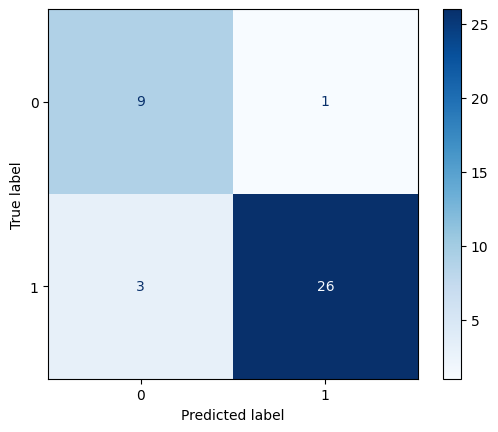

In [29]:
pred_probs=grid_search.predict_proba(X_test)[:,1]
preds=grid_search.predict(X_test)
accuracy=accuracy_score(Y_test,preds)
print("ACCURACY")
print(f"{accuracy*100}%")
print("CLASSIFICATION REPORT")
print(classification_report(Y_test,preds))
print("CONFUSION MATRIX")
ConfusionMatrixDisplay.from_predictions(Y_test, preds, cmap="Blues")
plt.show()

In [37]:
"""We remove Logistic Regression from our ensemble since it performs bad compared to the other models"""
from sklearn.ensemble import VotingClassifier
from sklearn.ensemble import StackingClassifier

ACCURACY
94.87179487179486%
CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.90      0.90      0.90        10
           1       0.97      0.97      0.97        29

    accuracy                           0.95        39
   macro avg       0.93      0.93      0.93        39
weighted avg       0.95      0.95      0.95        39

CONFUSION MATRIX


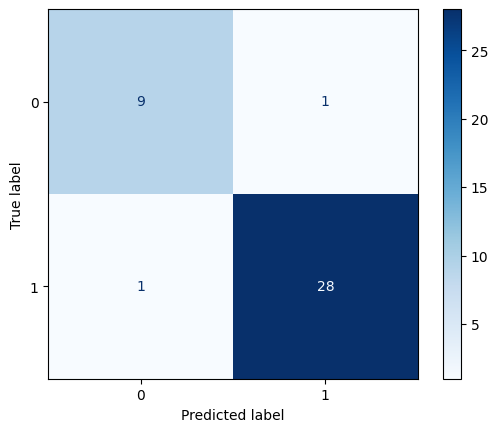

In [61]:
#VOTING CLASSIFIER(Soft Voting)
clf1=svm.SVC(C=10,class_weight="balanced",gamma="auto",kernel="rbf",probability=True)
clf2=XGBClassifier(colsample_bytree=1,gamma=0.01,grow_policy="lossguide",max_depth=8,n_estimators=250,reg_lambda=0.01,subsample=1)
clf3=RandomForestClassifier(max_leaf_nodes=12,min_samples_leaf=3,n_estimators=150,n_jobs=3)
voting_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("voting", VotingClassifier(
        estimators=[
            ('svc', clf1),
            ('xgb', clf2),
            ('rfc', clf3)
        ],
        voting='soft',
        
    ))
])

voting_pipeline.fit(X_train,Y_train)
vote_preds=voting_pipeline.predict(X_test)
accuracy2=accuracy_score(Y_test,vote_preds)
print("ACCURACY")
print(f"{accuracy2*100}%")
print("CLASSIFICATION REPORT")
print(classification_report(Y_test,vote_preds))
print("CONFUSION MATRIX")
ConfusionMatrixDisplay.from_predictions(Y_test,vote_preds, cmap="Blues")
plt.show()

ACCURACY
92.3076923076923%
CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.82      0.90      0.86        10
           1       0.96      0.93      0.95        29

    accuracy                           0.92        39
   macro avg       0.89      0.92      0.90        39
weighted avg       0.93      0.92      0.92        39

CONFUSION MATRIX


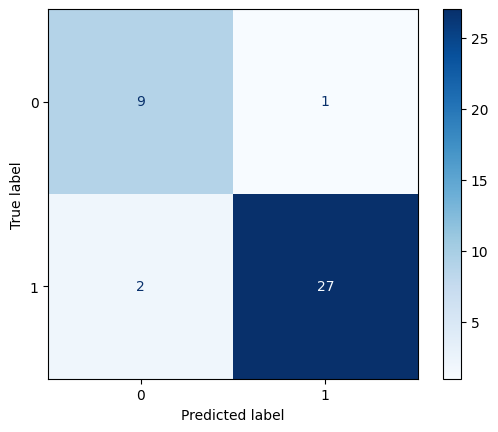

In [60]:
#STACKING
st = Pipeline([
    ("preprocessor", preprocessor),
    ("voting", StackingClassifier(
    estimators=[("svc",clf1),("xgb",clf2),("rfc",clf3)],
    cv=StratifiedKFold(n_splits=5,shuffle=True,random_state=42),
    final_estimator=LogisticRegression(),
    stack_method="predict_proba",
    passthrough=True
))
])
st.fit(X_train,Y_train)
st_preds=st.predict(X_test)
accuracy3=accuracy_score(Y_test,st_preds)
print("ACCURACY")
print(f"{accuracy3*100}%")
print("CLASSIFICATION REPORT")
print(classification_report(Y_test,st_preds))
print("CONFUSION MATRIX")
ConfusionMatrixDisplay.from_predictions(Y_test,st_preds, cmap="Blues")
plt.show()

# Conclusion

Based on the evaluation metrics, the best performing model was the Soft Voting Ensemble Classifier. The ensemble consisted of SVC, XGBoost, and Random Forest classifiers combined using soft voting.

Since the task involves Parkinson’s disease prediction, minimizing false negatives was considered highly important. The voting classifier achieved this objective effectively, producing only one false negative while also maintaining the highest overall accuracy among the tested models.

The individual models used in the ensemble produced relatively similar performance scores. During experimentation, it was observed that assigning excessively large weights to any single model reduced the effectiveness of the ensemble, likely due to a loss in model diversity. Equal weighting produced the best results, suggesting that maintaining balanced contributions from all models was more beneficial than heavily favoring the strongest standalone classifier.

Stacking classifiers were also tested, but their performance was slightly lower than the voting classifier by only one misclassified sample. Given the relatively small size of the dataset, even a single incorrect prediction causes a noticeable change in overall accuracy. Therefore, while the voting classifier performed best on the current split, the differences between the top performing ensemble approaches remain relatively small.

Another important observation during experimentation was that integrating preprocessing directly into the machine learning pipeline produced more reliable and methodologically correct evaluations by ensuring preprocessing transformations were consistently applied during both training and testing.

Overall, the soft voting ensemble demonstrated the best balance between accuracy, robustness, ensemble diversity, and reduction of false negatives for this dataset.

---

# Individual Model Metrics  
### Cross Validation Scores

| Model | Score |
|---|---|
| SVC | 0.956094 |
| XGBoostClassifier | 0.942284 |
| RandomForestClassifier | 0.940991 |
| LogisticRegression | 0.888181 *(Dropped from ensembling due to lower performance)* |

---

# Voting Classifier Metrics

| Metric | Value |
|---|---|
| True Positives | 28 |
| True Negatives | 9 |
| False Positives | 1 |
| False Negatives | 1 |
| Correctly Predicted Samples | 37 |
| Number of Test Samples | 39 |

---

# Final Accuracy

## 94.87%